<a href="https://colab.research.google.com/github/Alishba-Jawed/Airline-Passenger-Satisfaction-EDA/blob/main/Airline_Passenger_Satisfaction_Data_Cleaning_%26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**✈️ Airline Passenger Satisfaction Data Analysis**

**Dataset** : Airline Passenger Satisfaction

**Source** : Kaggle

**Rows** : 25,976

**Columns** : 10


**Objective** :

  This notebook analyzes the Airline Passenger Satisfaction dataset by performing data cleaning and exploratory data analysis (EDA). The goal is to understand the data, handle missing values, remove duplicates, and identify key patterns affecting customer satisfaction.

In [2]:
import pandas as pd
import numpy as np

In [3]:
#Load the Dataset
data = pd.read_csv("/content/messy_airline_filtered_final_removed_columns.csv")

In [4]:
#Preview of the Dataset
data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Food and drink,Departure Delay in Minutes,satisfaction
0,Female,LOYAL CUSTOMER,52.0,BUSINESS TRAVEL,eco,160.0,5.0,3.0,50.0,SaTiSfIeD
1,Female,loyal customer,36.0,business travel,Business,2863.0,1.0,5.0,0.0,Satisfied
2,Male,Disloyal Customer,20.0,Business travel,Eco,192.0,2.0,2.0,0.0,neutral or dissatisfied
3,male,LOYAL CUSTOMER,44.0,Business travel,business,3377.0,0.0,3.0,0.0,SaTiSfIeD
4,FeMaLe,Loyal Customer,49.0,Business travel,Eco,1182.0,2.0,4.0,0.0,SaTiSfIeD


In [5]:
print("Dataset shape :", data.shape)

Dataset shape : (25976, 10)


In [6]:
data.isnull().sum()

,0
Gender,57
Customer Type,96
Age,94
Type of Travel,85
Class,60
Flight Distance,105
Inflight wifi service,83
Food and drink,50
Departure Delay in Minutes,71
satisfaction,51


In [7]:
data.dtypes

,0
Gender,object
Customer Type,object
Age,object
Type of Travel,object
Class,object
Flight Distance,object
Inflight wifi service,float64
Food and drink,float64
Departure Delay in Minutes,object
satisfaction,object


In [8]:
data.duplicated().sum()

np.int64(17)

In [9]:
#Remove Duplicate Records
data = data.drop_duplicates(keep="first")

In [10]:
data = data.reset_index(drop= True)

In [11]:
data.duplicated().sum()

np.int64(0)

**GENDER Column**



In [12]:
data["Gender"].unique()

array(['Female', 'Male', 'male', 'FeMaLe', 'MaLe', ' Female ', 'FEMALE',
       'female', ' Male ', 'MALE', nan], dtype=object)

Issues:

1. Casing Issue
2. Spacing Issue
3. Having Null Values

In [13]:
data["Gender"]= data["Gender"].str.strip()
data["Gender"]= data["Gender"].str.title()

In [14]:
data["Gender"].unique()

array(['Female', 'Male', nan], dtype=object)

In [15]:
data["Gender"].mode()

,Gender
0,Female


In [16]:
data["Gender"]= data["Gender"].fillna(data["Gender"].mode()[0])

In [17]:
data["Gender"].unique()

array(['Female', 'Male'], dtype=object)

**CUSTOMER TYPE COLUMN**


In [18]:
data["Customer Type"].unique()

array(['LOYAL CUSTOMER', 'loyal customer', 'Disloyal Customer',
       'Loyal Customer', 'LoYaL CuStOmEr', ' Loyal Customer ',
       'DISLOYAL CUSTOMER', 'disloyal customer', 'disloyal Customer', nan,
       ' disloyal Customer ', 'Disloyal customer', 'Loyal customer'],
      dtype=object)

Issues:

1. Casing
2. WhiteSpacing
3. Null Values

In [19]:
data["Customer Type"]= data["Customer Type"].str.strip()
data["Customer Type"]= data["Customer Type"].str.title()

In [20]:
data["Customer Type"].unique()

array(['Loyal Customer', 'Disloyal Customer', nan], dtype=object)

In [21]:
data["Customer Type"].mode()

,Customer Type
0,Loyal Customer


In [22]:
data["Customer Type"] = data["Customer Type"].fillna(data["Customer Type"].mode()[0])

In [23]:
data["Customer Type"].unique()

array(['Loyal Customer', 'Disloyal Customer'], dtype=object)

**AGE COLUMN**


In [24]:
data["Age"].unique()

array(['52.0', '36.0', '20.0', ' 44.0 ', '49.0', '16.0', '77.0', '43.0',
       ' 47.0 ', '46.0', '47.0', '33.0', '60.0', '50.0', '31.0', '55.0',
       '25.0', '30.0', '62.0', '24.0', '22.0', '44.0', '51.0', '56.0',
       '41.0', ' 53.0 ', '12.0', ' 39.0 ', ' 32.0 ', '40.0', '42.0',
       '28.0', '59.0', '58.0', '53.0', '27.0', '67.0', '32.0', '70.0',
       '66.0', '19.0', '69.0', '35.0', '54.0', '26.0', '61.0', '21.0',
       '37.0', '45.0', '38.0', '7.0', '34.0', nan, '17.0', '15.0', '39.0',
       '48.0', '13.0', '11.0', '29.0', '8.0', '18.0', '23.0', '65.0',
       '57.0', '80.0', '64.0', '9.0', '14.0', '68.0', '10.0', '79.0',
       '63.0', '73.0', '74.0', '71.0', '72.0', '76.0', '15 min', '320.0',
       '78.0', '75.0', 'Unknown', '85.0', '1,250', ' 35 ', '?', 'Thirty',
       'none', '1250 km', '45mins'], dtype=object)

Issues:

1. Datatype
2. Null Values
3. Outlier Values

In [25]:
data["Age"]= pd.to_numeric(data["Age"], errors="coerce")

Age more than 80 consider as outlier

In [26]:
(data["Age"]>80).sum()

np.int64(16)

In [27]:
data.loc[data["Age"]>80, "Age"]=np.nan

In [28]:
data["Age"].isnull().sum()

np.int64(128)

In [29]:
data["Age"].median()

40.0

In [30]:
data["Age"] = data["Age"].fillna(data["Age"].median())

In [31]:
data["Age"].isnull().sum()

np.int64(0)

In [32]:
data["Age"] = data["Age"].astype(int)
data["Age"].dtype

dtype('int64')

In [33]:
data["Age"].unique()

array([52, 36, 20, 44, 49, 16, 77, 43, 47, 46, 33, 60, 50, 31, 55, 25, 30,
       62, 24, 22, 51, 56, 41, 53, 12, 39, 32, 40, 42, 28, 59, 58, 27, 67,
       70, 66, 19, 69, 35, 54, 26, 61, 21, 37, 45, 38,  7, 34, 17, 15, 48,
       13, 11, 29,  8, 18, 23, 65, 57, 80, 64,  9, 14, 68, 10, 79, 63, 73,
       74, 71, 72, 76, 78, 75])

**TYPE OF TRAVEL COLUMN**



In [34]:
data["Type of Travel"].unique()

array(['BUSINESS TRAVEL', 'business travel', ' Business travel ',
       'Business Travel', 'BuSiNeSs tRaVeL', 'PeRsOnAl tRaVeL',
       'PERSONAL TRAVEL', 'Personal Travel', 'personal travel',
       ' Personal Travel ', 'Business travel', nan, 'Personal travel',
       ' BUSINESS TRAVEL '], dtype=object)

Issues:

1. Spacing
2. Casing
3. Null Values



In [35]:
data["Type of Travel"] = data["Type of Travel"].str.strip()
data["Type of Travel"] = data["Type of Travel"].str.title()

In [36]:
data["Type of Travel"].isnull().sum()

np.int64(85)

In [37]:
data["Type of Travel"].mode()

,Type of Travel
0,Business Travel


In [38]:
data["Type of Travel"]= data["Type of Travel"].fillna(data["Type of Travel"].mode()[0])

In [39]:
data["Type of Travel"].isnull().sum()

np.int64(0)

In [40]:
data["Type of Travel"].unique()

array(['Business Travel', 'Personal Travel'], dtype=object)

**CLASS COLUMN**



In [41]:
data["Class"].unique()

array(['eco', ' Business ', ' Eco ', 'business', 'EcO', 'BuSiNeSs', 'ECO',
       'Business', 'BUSINESS', ' Eco Plus ', 'Eco', 'Eco Plus', nan,
       'ECO PLUS', 'eco plus', 'Eco plus'], dtype=object)

Issues:
1. Casing
2. Spacing
3. Null Values
4. Outliers

In [42]:
data["Class"] = data["Class"].str.strip()
data["Class"] = data["Class"].str.title()

In [43]:
data["Class"].isnull().sum()

np.int64(60)

In [44]:
data["Class"].mode()

,Class
0,Business


In [45]:
data["Class"] = data["Class"].fillna(data["Class"].mode()[0])

In [46]:
data["Class"].isnull().sum()

np.int64(0)

In [47]:
data["Class"].unique()

array(['Eco', 'Business', 'Eco Plus'], dtype=object)

**FLIGHT DISTANCE COLUMN**


In [48]:
data["Flight Distance"].unique()

array(['160.0', '2863.0', ' 192.0 ', ..., '3714.0', '3097.0', '3518.0'],
      dtype=object)

Issues:
1. Outlier
2. Null values
3. Datatype

In [49]:
data["Flight Distance"]= pd.to_numeric(data["Flight Distance"], errors= "coerce")

In [50]:
(data["Flight Distance"]> 3000).sum()


np.int64(2050)

In [51]:
(data["Flight Distance"]< 200).sum()

np.int64(1747)

In [52]:
data.loc[data["Flight Distance"]< 200, "Flight Distance"] = np.nan
data.loc[data["Flight Distance"]> 3000, "Flight Distance"] = np.nan

In [53]:
data["Flight Distance"].isnull().sum()

np.int64(3915)

In [54]:
data["Flight Distance"].median()

835.0

In [55]:
data["Flight Distance"]= data["Flight Distance"].fillna(data["Flight Distance"].median())

In [56]:
data["Flight Distance"].isnull().sum()

np.int64(0)

In [57]:
data["Flight Distance"] = data["Flight Distance"].astype(int)

In [58]:
data["Flight Distance"].unique()

array([ 835, 2863, 1182, ..., 1112, 2962, 1978])

**INFLIGHT WIFI SERVICE**


In [59]:
data["Inflight wifi service"].unique()

array([ 5.,  1.,  2.,  0.,  3.,  4., nan, 24.])

In [60]:
data["Inflight wifi service"].isnull().sum()

np.int64(83)

Issues:
1. Null Values
2. float dataype
3. Outlier

In [61]:
(data["Inflight wifi service"]>5).sum()

np.int64(8)

In [62]:
data.loc[data["Inflight wifi service"]>5, "Inflight wifi service"] = np.nan

In [63]:
data["Inflight wifi service"].isnull().sum()

np.int64(91)

In [64]:
data["Inflight wifi service"].mode()

,Inflight wifi service
0,2.0


In [65]:
data['Inflight wifi service']= data['Inflight wifi service'].fillna(data['Inflight wifi service'].mode()[0])

In [66]:
data["Inflight wifi service"].isnull().sum()

np.int64(0)

In [67]:
data["Inflight wifi service"] = data["Inflight wifi service"].astype(int)

In [68]:
data["Inflight wifi service"].unique()

array([5, 1, 2, 0, 3, 4])

**FOOD AND DRINK COLUMN**


In [69]:
data["Food and drink"].unique()

array([ 3.,  5.,  2.,  4.,  1., nan, 24.,  0.])

In [70]:
data["Food and drink"].isnull().sum()

np.int64(50)

Issues:
1. Null Values
2. float dataype
3. Outlier

In [71]:
(data["Food and drink"]> 5).sum()

np.int64(8)

In [72]:
data.loc[data["Food and drink"]>5, "Food and drink"] = np.nan

In [73]:
data["Food and drink"].isnull().sum()

np.int64(58)

In [74]:
data["Food and drink"].median()

3.0

In [75]:
data["Food and drink"] = data["Food and drink"].fillna(data["Food and drink"].median())

In [76]:
data["Food and drink"].isnull().sum()

np.int64(0)

In [77]:
data["Food and drink"] = data["Food and drink"].astype(int)

In [78]:
data["Food and drink"].unique()

array([3, 5, 2, 4, 1, 0])

**DEPARTURE DELAY IN MINUTES COLUMN**


In [79]:
data["Departure Delay in Minutes"].unique()

array(['50.0', '0.0', ' 0.0 ', '77.0', ' 1.0 ', '28.0', '29.0', '18.0',
       '117.0', '10.0', '5.0', '2.0', '8.0', ' 21.0 ', '3.0', '40.0',
       ' 80.0 ', '73.0', ' 4.0 ', '116.0', '59.0', '92.0', '4.0', '20.0',
       '17.0', '30.0', '66.0', '9.0', '6.0', '14.0', '49.0', '44.0',
       '24.0', '1.0', '7.0', '83.0', '13.0', '62.0', '16.0', '27.0',
       '94.0', '93.0', '180.0', '86.0', nan, '82.0', '32.0', '100.0',
       '25.0', '34.0', '90.0', '23.0', '168.0', '96.0', '45.0', '35.0',
       '85.0', '11.0', '26.0', '102.0', '12.0', '33.0', '19.0', '15.0',
       '57.0', '51.0', '243.0', '152.0', '38.0', '42.0', '47.0', '60.0',
       '91.0', '52.0', '238.0', '21.0', '150.0', '37.0', '71.0', '89.0',
       '108.0', '141.0', '132.0', '87.0', '81.0', '70.0', '140.0', '43.0',
       '41.0', '214.0', '63.0', '109.0', '145.0', '97.0', '56.0', '48.0',
       '114.0', '277.0', '22.0', '129.0', '493.0', '72.0', '332.0',
       '36.0', '125.0', '55.0', '136.0', '31.0', '64.0', '416.0', '46

Issues:
1. Outliers
2. Datatype
3. Null value

In [80]:
data["Departure Delay in Minutes"] = pd.to_numeric(data["Departure Delay in Minutes"], errors= "coerce")

In [81]:
(data["Departure Delay in Minutes"]>150) .sum()

np.int64(340)

In [82]:
(data["Departure Delay in Minutes"]< 10) .sum()

np.int64(18686)

In [83]:
data.loc[data["Departure Delay in Minutes"]> 150, "Departure Delay in Minutes"] = np.nan
data.loc[data["Departure Delay in Minutes"]< 10, "Departure Delay in Minutes"] = np.nan

In [84]:
data["Departure Delay in Minutes"]. isnull().sum()

np.int64(19115)

In [85]:
data["Departure Delay in Minutes"].median()

29.0

In [86]:
data["Departure Delay in Minutes"] = data["Departure Delay in Minutes"].fillna(data["Departure Delay in Minutes"].median())

In [87]:
data["Departure Delay in Minutes"].isnull().sum()

np.int64(0)

In [88]:
data["Departure Delay in Minutes"]= data["Departure Delay in Minutes"].astype(int)

In [89]:
data["Departure Delay in Minutes"].unique()

array([ 50,  29,  77,  28,  18, 117,  10,  21,  40,  80,  73, 116,  59,
        92,  20,  17,  30,  66,  14,  49,  44,  24,  83,  13,  62,  16,
        27,  94,  93,  86,  82,  32, 100,  25,  34,  90,  23,  96,  45,
        35,  85,  11,  26, 102,  12,  33,  19,  15,  57,  51,  38,  42,
        47,  60,  91,  52, 150,  37,  71,  89, 108, 141, 132,  87,  81,
        70, 140,  43,  41,  63, 109, 145,  97,  56,  48, 114,  22, 129,
        72,  36, 125,  55, 136,  31,  64,  46,  58,  39, 105,  68, 113,
       124, 137,  53,  79, 126,  75,  98,  88,  69, 146,  74, 118,  54,
       130, 142,  99,  67, 104,  61,  65, 106, 107, 120, 101, 143, 144,
       135, 121, 115, 138, 149, 134,  76, 131,  84, 103, 111, 123,  78,
       139, 128, 148, 110, 112, 127,  95, 147, 122, 119, 133])

**SATISFACTION COLUMN**


In [90]:
data["satisfaction"].unique()

array(['SaTiSfIeD', 'Satisfied', ' neutral or dissatisfied ',
       ' satisfied ', 'SATISFIED', 'satisfied', 'NEUTRAL OR DISSATISFIED',
       'NeUtRaL Or dIsSaTiSfIeD', 'Neutral Or Dissatisfied',
       'neutral or dissatisfied', nan, 'Neutral or Dissatisfied'],
      dtype=object)

Issues:
1. Null Vaues
2. Spacing
3. Casing
4. Not Required Term

In [91]:
data["satisfaction"] = data["satisfaction"].str.strip()
data["satisfaction"] = data["satisfaction"].str.title()

In [92]:
data['satisfaction'].isnull().sum()

np.int64(51)

In [93]:
data['satisfaction'].mode()

,satisfaction
0,Neutral Or Dissatisfied


In [94]:
data['satisfaction'] = data['satisfaction'].fillna(data['satisfaction'].mode()[0])

In [95]:
data['satisfaction'].isnull().sum()

np.int64(0)

In [96]:
data['satisfaction'] = data["satisfaction"].replace("Neutral Or Dissatisfied", 'Not Satisfied', regex= False)

In [97]:
data['satisfaction'].unique()

array(['Satisfied', 'Not Satisfied'], dtype=object)

**CHECK THE DATA**

In [98]:
data

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Food and drink,Departure Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business Travel,Eco,835,5,3,50,Satisfied
1,Female,Loyal Customer,36,Business Travel,Business,2863,1,5,29,Satisfied
2,Male,Disloyal Customer,20,Business Travel,Eco,835,2,2,29,Not Satisfied
3,Male,Loyal Customer,44,Business Travel,Business,835,0,3,29,Satisfied
4,Female,Loyal Customer,49,Business Travel,Eco,1182,2,4,29,Satisfied
...,...,...,...,...,...,...,...,...,...,...
25954,Male,Disloyal Customer,34,Business Travel,Business,526,3,4,29,Not Satisfied
25955,Male,Loyal Customer,23,Business Travel,Business,646,4,4,29,Satisfied
25956,Female,Loyal Customer,17,Personal Travel,Eco,828,2,2,29,Not Satisfied
25957,Male,Loyal Customer,14,Business Travel,Business,1127,3,4,29,Satisfied


In [99]:
data.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Food and drink,0
Departure Delay in Minutes,0
satisfaction,0


In [100]:
data.dtypes

,0
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Food and drink,int64
Departure Delay in Minutes,int64
satisfaction,object


**DATA TRANSFORMATION**

In [101]:
def grouping(Delay):
  if Delay >=  90:
    return 'Major'
  elif Delay >= 30:
    return 'Moderate'
  elif Delay >= 10:
    return 'Minor'
  else:
    return 'No Delay'

data['Delay Category'] = data["Departure Delay in Minutes"].apply(grouping)



In [102]:
data

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Food and drink,Departure Delay in Minutes,satisfaction,Delay Category
0,Female,Loyal Customer,52,Business Travel,Eco,835,5,3,50,Satisfied,Moderate
1,Female,Loyal Customer,36,Business Travel,Business,2863,1,5,29,Satisfied,Minor
2,Male,Disloyal Customer,20,Business Travel,Eco,835,2,2,29,Not Satisfied,Minor
3,Male,Loyal Customer,44,Business Travel,Business,835,0,3,29,Satisfied,Minor
4,Female,Loyal Customer,49,Business Travel,Eco,1182,2,4,29,Satisfied,Minor
...,...,...,...,...,...,...,...,...,...,...,...
25954,Male,Disloyal Customer,34,Business Travel,Business,526,3,4,29,Not Satisfied,Minor
25955,Male,Loyal Customer,23,Business Travel,Business,646,4,4,29,Satisfied,Minor
25956,Female,Loyal Customer,17,Personal Travel,Eco,828,2,2,29,Not Satisfied,Minor
25957,Male,Loyal Customer,14,Business Travel,Business,1127,3,4,29,Satisfied,Minor


In [103]:
def grading(Distance):
  if Distance >=  2000:
    return 'Very Long'
  elif Distance >= 1500:
    return 'Long'
  elif Distance >= 500:
    return 'Medium'
  else:
    return 'Short'

data['Distance Category'] = data['Flight Distance'].apply(grading)

In [104]:
def grading(Age):
  if Age >= 50:
    return 'Old'
  elif Age >= 30:
    return 'Adult'
  elif Age >= 20:
    return 'Young'
  elif Age <= 19:
    return 'Teen-Age'
  else:
    return 'Child'

data['Age Group'] = data['Age'].apply(grading)

In [105]:
data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Food and drink,Departure Delay in Minutes,satisfaction,Delay Category,Distance Category,Age Group
0,Female,Loyal Customer,52,Business Travel,Eco,835,5,3,50,Satisfied,Moderate,Medium,Old
1,Female,Loyal Customer,36,Business Travel,Business,2863,1,5,29,Satisfied,Minor,Very Long,Adult
2,Male,Disloyal Customer,20,Business Travel,Eco,835,2,2,29,Not Satisfied,Minor,Medium,Young
3,Male,Loyal Customer,44,Business Travel,Business,835,0,3,29,Satisfied,Minor,Medium,Adult
4,Female,Loyal Customer,49,Business Travel,Eco,1182,2,4,29,Satisfied,Minor,Medium,Adult


In [106]:
data.shape

(25959, 13)

**VSUALIZATION**

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

**Bar Plot**

In [108]:
Age_count = data["Age Group"].value_counts()
Age_count

,count
Age Group,
Adult,11054
Old,7315
Young,5237
Teen-Age,2353


In [109]:
Age_count.index

Index(['Adult', 'Old', 'Young', 'Teen-Age'], dtype='object', name='Age Group')

In [110]:
Age_count.values

array([11054,  7315,  5237,  2353])

**Bar Plot**

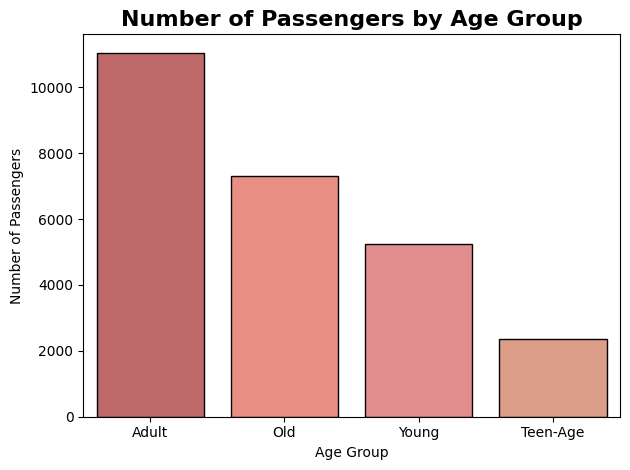

In [111]:
colors = ["indianred", "salmon", "lightcoral", "darksalmon"]
sns.barplot(x= Age_count.index, y= Age_count.values,hue=Age_count.index, palette=colors,legend = False, edgecolor = "black")
plt.ylabel("Number of Passengers")
plt.title("Number of Passengers by Age Group", fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [112]:
class_count= data["Class"].value_counts()
class_count

,count
Class,
Business,12523
Eco,11523
Eco Plus,1913


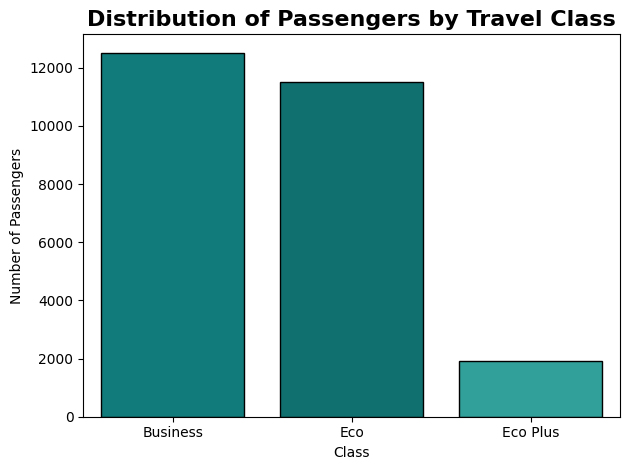

In [113]:
colors =["darkcyan", "teal", "lightseagreen"]
sns.barplot(x = class_count.index,y = class_count.values, hue = class_count.index, legend=False, edgecolor= "black", palette = colors)
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passengers by Travel Class", fontsize = 16, fontweight = "bold")
plt.tight_layout()
plt.show()

In [114]:
travel_count = data["Type of Travel"].value_counts()

In [115]:
travel_count

,count
Type of Travel,
Business Travel,18063
Personal Travel,7896


/tmp/ipykernel_926/3533818487.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot (x= travel_count.index, y= travel_count.values, palette = colors, edgecolor = "black")


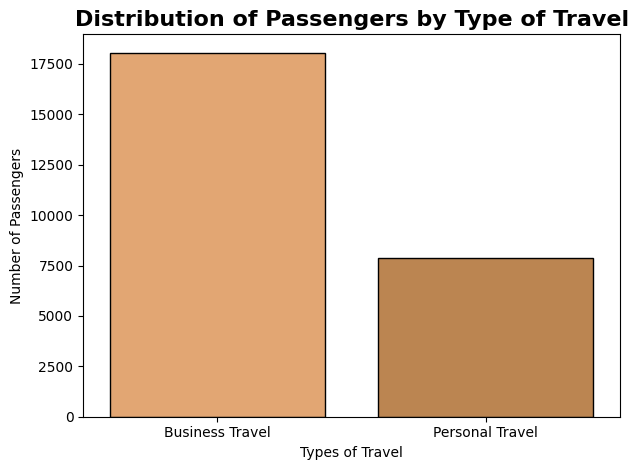

In [116]:
colors = ["sandybrown", "peru"]
#colors = ["lightblue", "powderblue"]
#colors = ["paleturquoise", "lightblue"]

sns.barplot (x= travel_count.index, y= travel_count.values, palette = colors, edgecolor = "black")
plt.xlabel("Types of Travel")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passengers by Type of Travel", fontsize = 16, fontweight = "bold")
plt.tight_layout()
plt.show()

**Pie Chart**

In [117]:
Satisfaction_count =data["satisfaction"].value_counts()

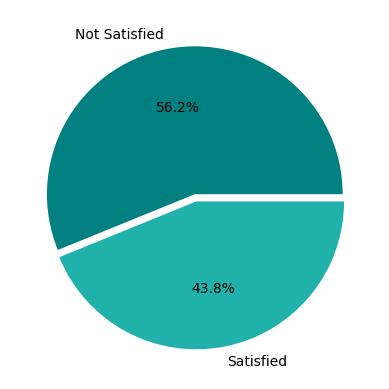

In [118]:
plt.pie(Satisfaction_count.values, labels= Satisfaction_count.index, autopct='%1.1f%%', explode=[0,0.05], colors= ["teal", "lightseagreen"])
plt.show()

In [119]:
Gender_count =data["Gender"].value_counts()

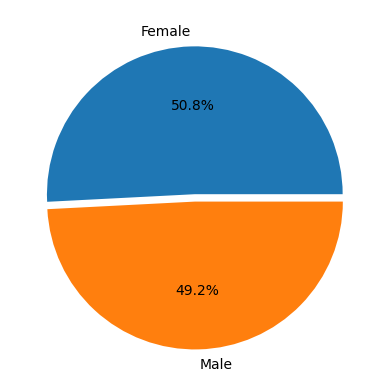

In [120]:
plt.pie(Gender_count.values, labels= Gender_count.index, autopct='%1.1f%%', explode=[0,0.05])
plt.show()

## Conclusion

- The dataset was successfully cleaned and preprocessed.
- Missing values and duplicate records were handled appropriately.
- Exploratory Data Analysis (EDA) provided valuable insights into passenger satisfaction.
- This project demonstrates the complete data preprocessing and exploratory analysis workflow using Python.